In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity

files = {
    "GAT": "GAT.csv",
    "GCN": "GCN_cfg01.csv",
    "GraphSAGE": "GraphSage.csv",
    "Linear": "Linear.csv"
}

features = pd.read_csv("player_features.csv")
ID_COL = "player_id"

def parse_embedding(s):
    s = str(s).strip()
    if s.startswith("[") and s.endswith("]"):
        s = s[1:-1]
    return np.array([float(x) for x in s.split()])

models = {}

for model_name, fname in files.items():
    emb = pd.read_csv(fname)
    emb["embedding"] = emb["final_embedding"].apply(parse_embedding)
    X = np.vstack(emb["embedding"].values)
    df = emb.merge(features, on=ID_COL, how="left")
    df["emb_matrix"] = list(X)
    models[model_name] = df

In [7]:
summary_rows = []

for model_name, df in models.items():
    X = np.vstack(df["emb_matrix"].values)
    norms = np.linalg.norm(X, axis=1)

    # PCA
    pca = PCA(n_components=5)
    pca.fit(X)

    # Clusters
    kmeans = KMeans(n_clusters=5, random_state=42, n_init="auto")
    labels = kmeans.fit_predict(X)
    sil = silhouette_score(X, labels)

    summary_rows.append({
        "Model": model_name,
        "Mean Norm": norms.mean(),
        "Std Norm": norms.std(),
        "PCA Var PC1": pca.explained_variance_ratio_[0],
        "PCA Var PC2": pca.explained_variance_ratio_[1],
        "Silhouette Score": sil
    })

summary_table = pd.DataFrame(summary_rows)
summary_table

,Model,Mean Norm,Std Norm,PCA Var PC1,PCA Var PC2,Silhouette Score
0,GAT,1.314205,0.588036,0.995365,0.004538,0.574782
1,GCN,0.687528,0.235806,0.984232,0.011514,0.515118
2,GraphSAGE,1.942137,0.942524,0.995110,0.004834,0.575114
3,Linear,1.626421,0.641783,0.992380,0.006006,0.483541


In [8]:
perf_cols = []
for c in features.columns:
    if features[c].dtype != 'object' and c != ID_COL:
        perf_cols.append(c)

perf_rows = []

for model_name, df in models.items():
    X = np.vstack(df["emb_matrix"].values)
    norms = np.linalg.norm(X, axis=1)

    row = {"Model": model_name}
    for col in perf_cols:
        if col in df.columns:
            row[f"Corr(norm, {col})"] = np.corrcoef(norms, df[col])[0,1]
    perf_rows.append(row)

perf_table = pd.DataFrame(perf_rows)
perf_table

,Model,"Corr(norm, current_rank)","Corr(norm, hand)","Corr(norm, dob)","Corr(norm, height)","Corr(norm, country_num)"
0,GAT,0.693519,-0.030590,0.031530,-0.211137,0.244722
1,GCN,0.226357,0.029466,0.134243,-0.032403,0.037408
2,GraphSAGE,0.820603,0.002702,-0.120333,-0.348240,0.247234
3,Linear,0.819160,-0.017143,-0.115848,-0.354869,0.302887


In [10]:
def neighbor_consistency(X, perf, k=5):
    sim = cosine_similarity(X)
    scores = []
    for i in range(len(X)):
        nn = np.argsort(-sim[i])[1:k+1]
        scores.append(np.std(perf[nn]))
    return np.mean(scores)

nc_rows = []

for model_name, df in models.items():
    X = np.vstack(df["emb_matrix"].values)
    if "ranking" in df.columns:
        nc = neighbor_consistency(X, df["ranking"].values)
        nc_rows.append({"Model": model_name, "Neighbor Consistency (ranking std)": nc})

nc_table = pd.DataFrame(nc_rows)
nc_table

""


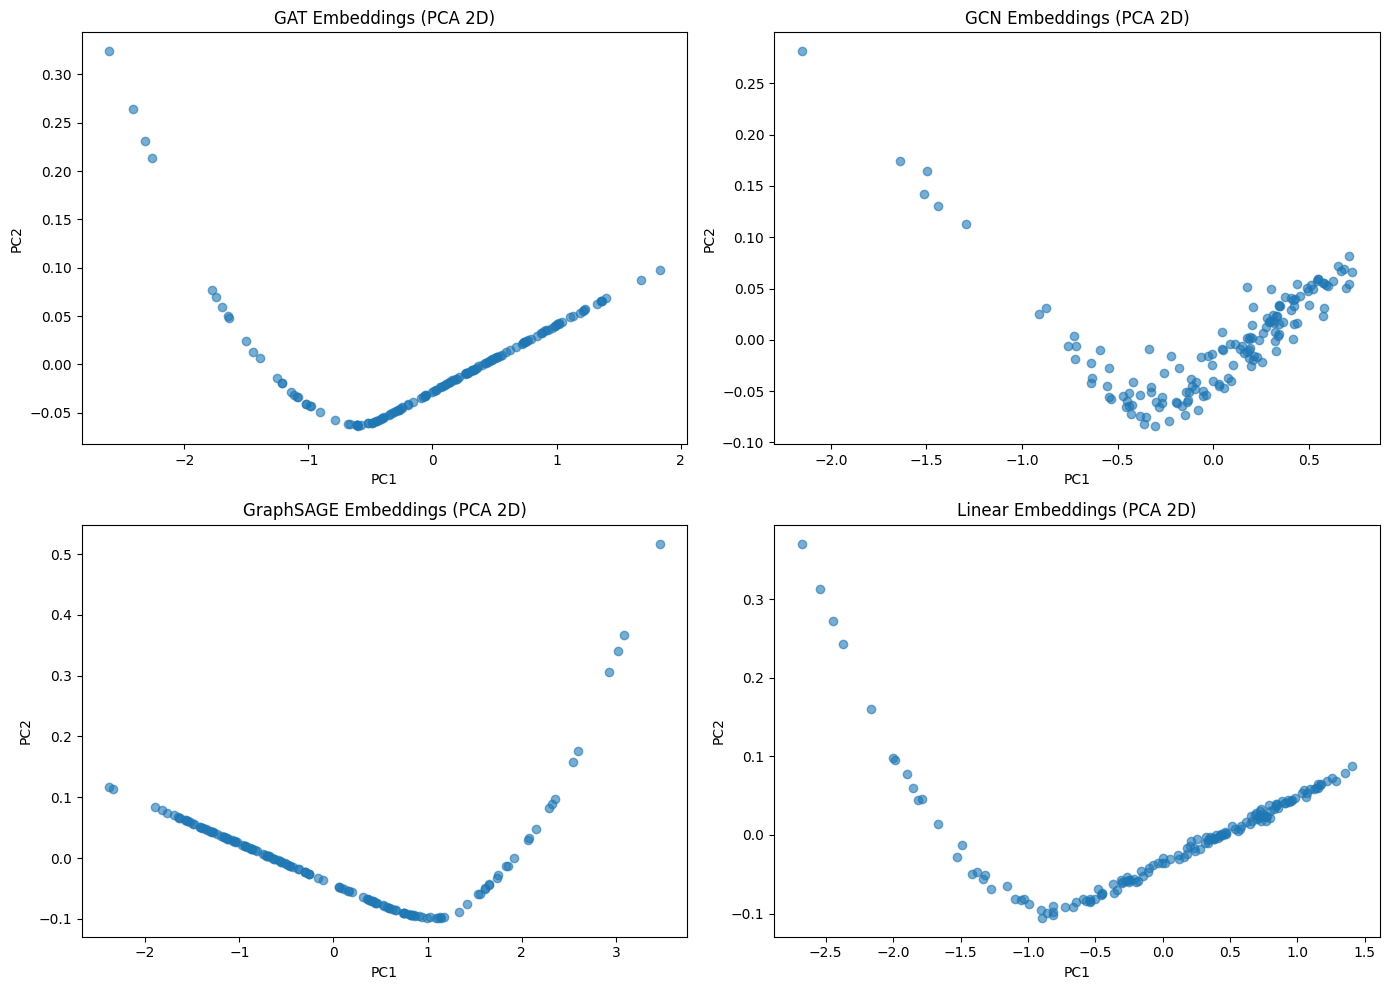

In [11]:
plt.figure(figsize=(14, 10))

i = 1
for model_name, df in models.items():
    X = np.vstack(df["emb_matrix"].values)
    pca = PCA(n_components=2)
    pcs = pca.fit_transform(X)

    plt.subplot(2, 2, i)
    plt.scatter(pcs[:,0], pcs[:,1], alpha=0.6)
    plt.title(f"{model_name} Embeddings (PCA 2D)")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    i += 1

plt.tight_layout()
plt.show()

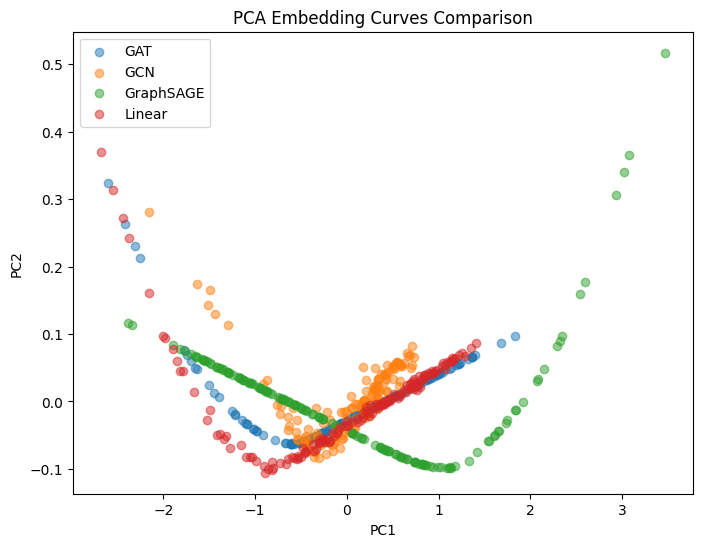

In [12]:
plt.figure(figsize=(8,6))

for model_name, df in models.items():
    X = np.vstack(df["emb_matrix"].values)
    pcs = PCA(n_components=2).fit_transform(X)
    plt.scatter(pcs[:,0], pcs[:,1], alpha=0.5, label=model_name)

plt.title("PCA Embedding Curves Comparison")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()